In [13]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
local_src = str(project_root / 'src')
sys.path = [entry for entry in sys.path if entry != local_src]
sys.path.insert(0, local_src)
for module_name in list(sys.modules):
    if module_name == 'asispectralinversion' or module_name.startswith('asispectralinversion.'):
        del sys.modules[module_name]

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import h5py
import scipy.interpolate
from matplotlib.pyplot import figure
import glob
import imageio.v3 as iio


# from asispectralinversion.inversion import *
# from asispectralinversion.preprocessing import *
# from asispectralinversion.pullfiles import *
from asispectralinversion.filing import *
from asispectralinversion.transformation import *
from asispectralinversion.inversion import *
from asispectralinversion.preprocessing import *
import datetime as dt


#from asi_inv import *
from apexpy import Apex

# Copies an HDF5 structure to a python dict recursively
def copy_h5(vtest):
    # Initialize dict to output
    dicttest = {}
    # List of keys in dataset
    keyslist = list(vtest.keys())
    # Iterate through keys
    for key in keyslist:
        # vtest[key] is an array
        if type(vtest[key]) == h5py._hl.dataset.Dataset:
            # vtest[key] is a 0d or 1d array
            if vtest[key].shape[1] == 1:
                # vtest[key] is a 0d array
                if vtest[key].shape[0] == 1:
                    # extract the float value of vtest[key]
                    dicttest[key] = vtest[key][0][0]
                # vtest[key] is a 1d array
                else:
                    # extract the numpy array
                    dicttest[key] = np.asarray(vtest[key]).flatten()
            # vtest[key] is a 2 or more dimensional array
            else:
                # extract the numpy array
                dicttest[key] = np.asarray(vtest[key])
        # vtest[key] is another hdf5 structure
        else:
            # Recursively apply copy_h5 to the sub-structure
            dicttest[key] = copy_h5(vtest[key])
    return dicttest

In [14]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
local_src = str(project_root / 'src')
sys.path = [entry for entry in sys.path if entry != local_src]
sys.path.insert(0, local_src)
for module_name in list(sys.modules):
    if module_name == 'asispectralinversion' or module_name.startswith('asispectralinversion.'):
        del sys.modules[module_name]

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import h5py
import scipy.interpolate
from matplotlib.pyplot import figure
import glob
import imageio.v3 as iio
import datetime as dt

from asispectralinversion.filing import *
from asispectralinversion.transformation import *
from asispectralinversion.inversion import *
from asispectralinversion.preprocessing import *


# THINGS TO ADD:

## - Add second order inversion

# Set Parameters

In [15]:
date = '20260210'
#date = '20230319'
dtdate = dt.date(int(date[:4]),int(date[4:6]),int(date[6:]))
lookup_root = project_root / 'GLOW_lookup_tables' / 'GNEISS' / date[2:] / '102400'
lookup_site = 'VEE'

# These aren't necessary with wavelet denoising
# Gaussian blur width in degrees maglon
blur_deg_EW = 0.4
# Gaussian blur width in degrees maglat (should be smaller!)
blur_deg_NS = 0.04

# n_shifts, integer determining shift-invariance of wavelets (higher is better, but slower and has diminishing returns)
n_shifts = 30

# Do we use dark patches in the sky to set background brightness, or just use the corners?
background_method = 'corners'


# Test Inversion
Let's start with a quick self-test: after reading in our inversion tables, we sample RGB brightnesses and see how well we can invert back to what we started with

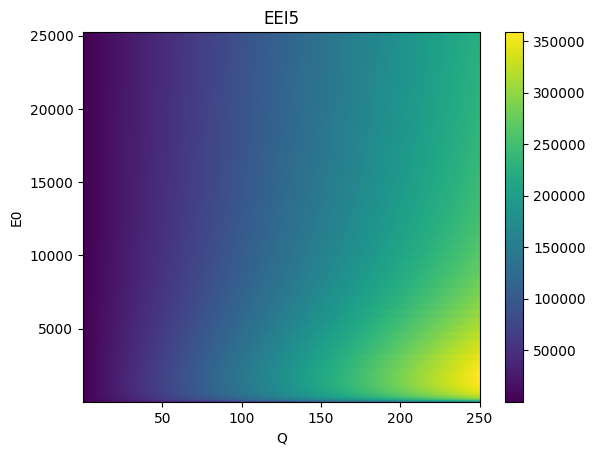

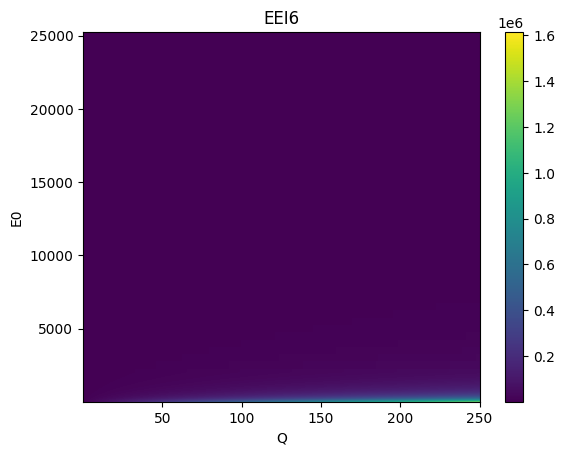

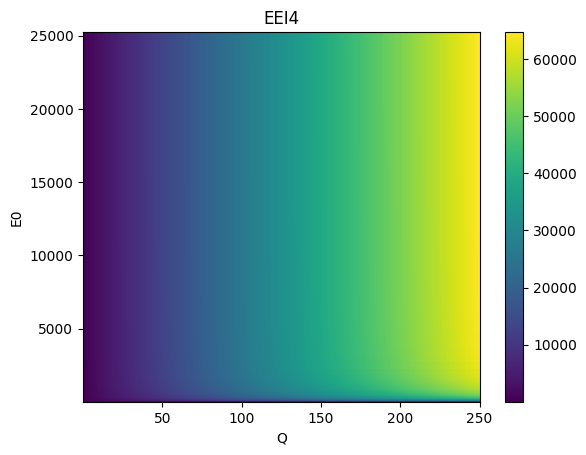

In [16]:
def one_lookup_file(pattern):
    matches = sorted(pattern.parent.glob(pattern.name))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected one match for {pattern}, found {len(matches)}')
    return str(matches[0])

def load_site_lookup(site, plot=True):
    def main_file(stem):
        return one_lookup_file(lookup_root / f'{site}{stem}*.bin')

    airglow_dir = lookup_root / site / 'airglow'
    lookup = load_lookup_tables(
        main_file('I6300'), main_file('I5577'), main_file('I4278'),
        main_file('ped3d'), main_file('hall3d'), main_file('edens3d'),
        plot=plot,
    )
    airglow = load_lookup_tables(
        one_lookup_file(airglow_dir / 'I6300*.bin'),
        one_lookup_file(airglow_dir / 'I5577*.bin'),
        one_lookup_file(airglow_dir / 'I4278*.bin'),
        one_lookup_file(airglow_dir / 'ped3d*.bin'),
        one_lookup_file(airglow_dir / 'hall3d*.bin'),
        one_lookup_file(airglow_dir / 'edens3d*.bin'),
        plot=False,
    )
    lookup['redbright_airglow'] = airglow['redmat']
    lookup['greenbright_airglow'] = airglow['greenmat']
    lookup['bluebright_airglow'] = airglow['bluemat']
    lookup['sigP_bg'] = airglow['sigPmat']
    lookup['sigH_bg'] = airglow['sigHmat']
    lookup['SigP_bg'] = airglow['SigPmat']
    lookup['SigH_bg'] = airglow['SigHmat']
    return lookup

v = load_site_lookup(lookup_site, plot=True)

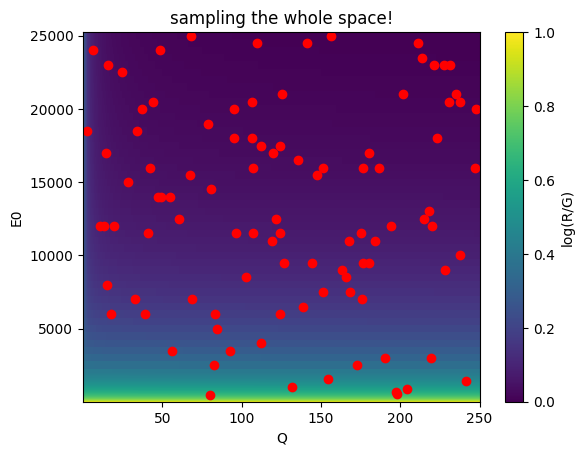

In [17]:
# select random E0 and Q values
randE0 = np.random.random(100)*(np.max(v['E0vec'])-np.min(v['E0vec'])) + np.min(v['E0vec'])
randQ = np.random.random(100)*(np.max(v['Qvec'])-np.min(v['Qvec'])) + np.min(v['Qvec'])

# find closest indices and "snap" to grid
idxE0 = np.array([np.argmin(np.abs(v['E0vec']-E0)) for E0 in randE0])
idxQ = np.array([np.argmin(np.abs(v['Qvec']-Q)) for Q in randQ])
testE0 = v['E0vec'][idxE0]
testQ = v['Qvec'][idxQ]

# Plot
plt.pcolormesh(v['Qvec'],v['E0vec'],np.log(v['redmat']/v['greenmat']))
plt.scatter(testQ,testE0,color='red')
plt.xlabel('Q')
plt.ylabel('E0')
plt.colorbar(label='log(R/G)')
plt.title('sampling the whole space!')
plt.show()


In [18]:
# Pulling out RGB values
redtrace = v['redmat'][idxE0, idxQ]
greentrace = v['greenmat'][idxE0, idxQ]
bluetrace = v['bluemat'][idxE0, idxQ]

# Removing airglow
greentrace -= v['greenbright_airglow'][0][0]
redtrace -= v['redbright_airglow'][0][0]
bluetrace -= v['bluebright_airglow'][0][0]


## Three-Color Inversion
This is the standard and prefered technique.

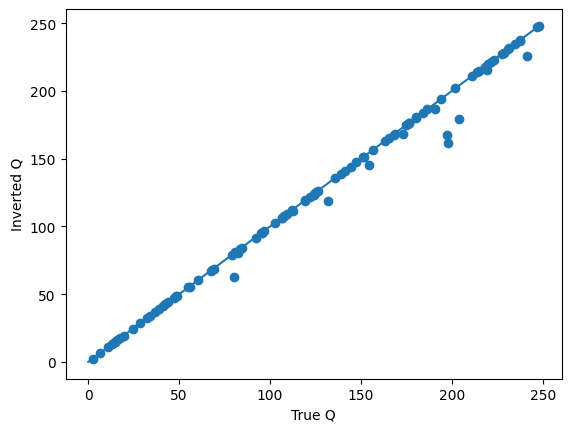

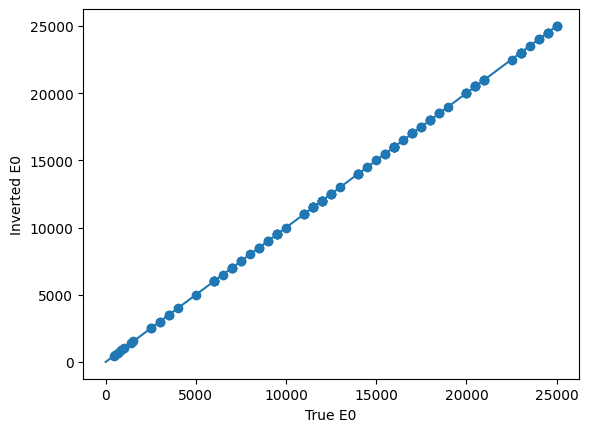

In [19]:
# Calculate E0 and Q from inversion
outQ, outE0 = calculate_E0_Q_v2(redtrace, greentrace, bluetrace, v, minE0=150, secondorder=True, generous=True, plot=False)

# Plot
plt.scatter(testQ, outQ)
plt.plot([0, np.max(testQ)], [0, np.max(testQ)])
plt.xlabel('True Q')
plt.ylabel('Inverted Q')
plt.show()

plt.scatter(testE0, outE0)
plt.plot([0, np.max(testE0)], [0, np.max(testE0)])
plt.xlabel('True E0')
plt.ylabel('Inverted E0')
plt.show()


In [20]:
# Assess variance from truth value
print('Q chi2:', np.sum((outQ-testQ)**2/testQ))
print('Q med %err:', np.median(np.abs(outQ-testQ)/testQ*100.))
print('E0 chi2:', np.sum((outE0-testE0)**2/testE0))
print('E0 med %err:', np.median(np.abs(outE0-testE0)/testE0*100.))


Q chi2: 21.227093
Q med %err: 0.11955402
E0 chi2: 0.01019642
E0 med %err: 0.00028498642


## Red-Green Only
This is an experimental technique that may be useful if there are only two cameras available.

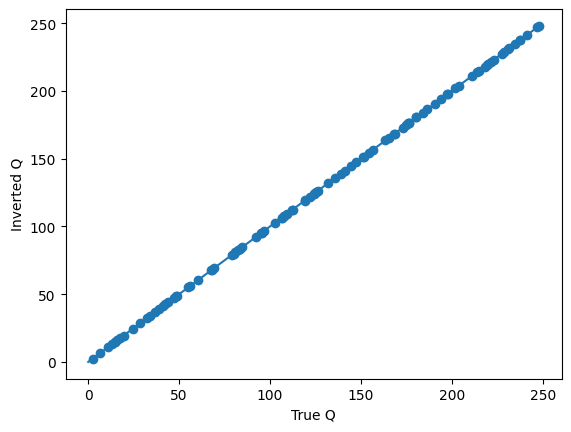

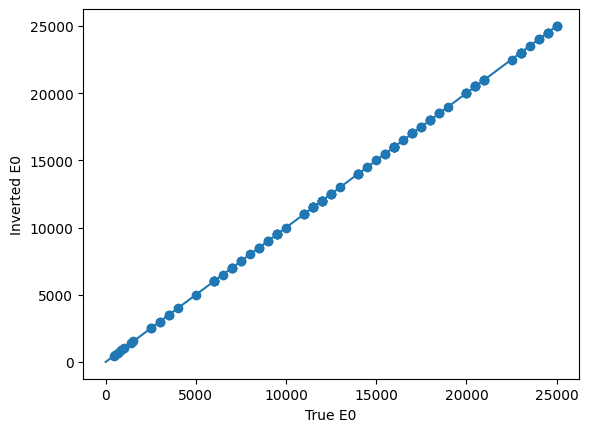

In [21]:
# Calculate E0 and Q from inversion
outQ, outE0 = calculate_E0_Q_v2_RGonly(redtrace,greentrace,bluetrace,v,minE0=150,checkagreement=False,cutoffgoodness=0.3,plot=False)

# Plot
plt.scatter(testQ, outQ)
plt.plot([0, np.max(testQ)], [0, np.max(testQ)])
plt.xlabel('True Q')
plt.ylabel('Inverted Q')
plt.show()

plt.scatter(testE0, outE0)
plt.plot([0, np.max(testE0)], [0, np.max(testE0)])
plt.xlabel('True E0')
plt.ylabel('Inverted E0')
plt.show()


In [22]:
# Assess variance from truth value
print('Q chi2:', np.sum((outQ-testQ)**2/testQ))
print('Q med %err:', np.median(np.abs(outQ-testQ)/testQ*100.))
print('E0 chi2:', np.sum((outE0-testE0)**2/testE0))
print('E0 med %err:', np.median(np.abs(outE0-testE0)/testE0*100.))


Q chi2: 0.002182552403533778
Q med %err: 7.686118042474991e-05
E0 chi2: 0.05939170045331121
E0 med %err: 1.7832151368363866e-07


# Inversion of Imagry Data
Same technique, but applied to the local TIFF root selected in `config.toml`.


In [23]:
# Local TIFF imagery root. These files are already on disk, so no PKR DASC download is needed.
from asispectralinversion.config import load_config
run_config = load_config(project_root=project_root)
image_root = str(run_config.paths.image_root)
image_station = 'VEE'

# The red channel can use either the 630.0 or 844.6 nm emission line.
# Blue is always the 427.8 nm emission line.
red_wavelength_nm = 630.0
target_datetime = dt.datetime(2026, 2, 10, 10, 24, 0)  # UTC
frames_to_coadd = 3


## Read Images
Read the selected red wavelength (630.0 or 844.6 nm), green (557.7 nm), and blue (427.8 nm) images from local TIFF files.


In [24]:
# Read in local TIFF images for the selected station.
# Each VEE TIFF is a multipage stack. Select the file covering the target, then pages within it.
import os
import re
import tifffile

red_files_by_wavelength = {
    630.0: sorted(glob.glob(f'{image_root}/red/6300/{image_station}/GNEISS/*.tif*')),
    844.6: [f'{image_root}/red/8446/{image_station}/PLA260210_09595909_16bit.tif'],
}
green_files = sorted(glob.glob(f'{image_root}/green/{image_station}/GNEISS/*.tif*'))
blue_wavelength_nm = 427.8
blue_file = f'{image_root}/blue/{image_station}/SOK260210_101900_102848_16bit.tif'

# Timing comes from the acquisition/cache metadata accompanying these VEE stacks.
stack_timing = {
    844.6: (dt.datetime.fromisoformat('2026-02-10T10:00:00.005000'), 0.9020278195488721),
    427.8: (dt.datetime.fromisoformat('2026-02-10T10:19:00.756700'), 0.90178),
}
file_stack_cadence = {630.0: 0.9, 557.7: 0.3}

if red_wavelength_nm not in red_files_by_wavelength:
    raise ValueError(f'red_wavelength_nm must be one of {sorted(red_files_by_wavelength)}')
red_files = red_files_by_wavelength[red_wavelength_nm]
if red_wavelength_nm == 630.0 and not red_files:
    raise FileNotFoundError('No red 630.0 nm TIFF stacks found')
if red_wavelength_nm == 844.6 and not os.path.exists(red_files[0]):
    raise FileNotFoundError(f'Need red 844.6 nm TIFF stack: {red_files[0]}')
if not green_files:
    raise FileNotFoundError(f'No green TIFF stacks found in {image_root}/green/{image_station}/GNEISS')
if not os.path.exists(blue_file):
    raise FileNotFoundError(f'Need blue 427.8 nm TIFF stack: {blue_file}')

def read_tiff_frame(fname, frame_index=0):
    with tifffile.TiffFile(fname) as tif:
        if len(tif.pages) == 1:
            return tif.pages[0].asarray().astype(float)
        if frame_index < 0 or frame_index >= len(tif.pages):
            raise IndexError(f'Frame index {frame_index} is outside {fname}, which has {len(tif.pages)} frames')
        return tif.pages[frame_index].asarray().astype(float)

def read_tiff_frames(fname, frame_indices):
    return [read_tiff_frame(fname, idx) for idx in frame_indices]

def timestamp_from_frame_filename(fname):
    match = re.search(r'_(\d{8})_(\d{6})\.tiff?$', os.path.basename(fname), re.IGNORECASE)
    if not match:
        raise ValueError(f'Cannot parse frame timestamp from {fname}')
    return dt.datetime.strptime(''.join(match.groups()), '%Y%m%d%H%M%S')

def closest_stack_frames(fname, start_time, cadence_seconds, target, count):
    with tifffile.TiffFile(fname) as tif:
        page_count = len(tif.pages)
    center = round((target - start_time).total_seconds() / cadence_seconds)
    candidates = range(max(0, center - count), min(page_count, center + count + 1))
    selected = sorted(candidates, key=lambda idx: abs((start_time + dt.timedelta(seconds=idx * cadence_seconds)) - target))[:count]
    return sorted((start_time + dt.timedelta(seconds=idx * cadence_seconds), idx) for idx in selected)

def select_covering_tiff_frames(files, cadence_seconds, target, count):
    covering = []
    for fname in files:
        start_time = timestamp_from_frame_filename(fname)
        with tifffile.TiffFile(fname) as tif:
            page_count = len(tif.pages)
        end_time = start_time + dt.timedelta(seconds=(page_count - 1) * cadence_seconds)
        if start_time <= target <= end_time:
            covering.append((fname, start_time, end_time))
    if not covering:
        raise ValueError(f'No TIFF stack covers {target.isoformat()} UTC')
    fname, start_time, _ = min(covering, key=lambda item: abs(item[1] - target))
    selected = closest_stack_frames(fname, start_time, cadence_seconds, target, count)
    return fname, selected

if red_wavelength_nm == 630.0:
    red_file, selected_red = select_covering_tiff_frames(
        red_files, file_stack_cadence[630.0], target_datetime, frames_to_coadd
    )
    red_times = [frame_time for frame_time, _ in selected_red]
    red_images = read_tiff_frames(red_file, [idx for _, idx in selected_red])
else:
    red_file = red_files[0]
    red_start, red_cadence = stack_timing[844.6]
    selected_red = closest_stack_frames(red_file, red_start, red_cadence, target_datetime, frames_to_coadd)
    red_times = [frame_time for frame_time, _ in selected_red]
    red_images = read_tiff_frames(red_file, [idx for _, idx in selected_red])
redim0, redim1, redim2 = red_images

green_file, selected_green = select_covering_tiff_frames(
    green_files, file_stack_cadence[557.7], target_datetime, frames_to_coadd
)
green_times = [frame_time for frame_time, _ in selected_green]
greenim0, greenim1, greenim2 = read_tiff_frames(green_file, [idx for _, idx in selected_green])

blue_start, blue_cadence = stack_timing[427.8]
selected_blue = closest_stack_frames(blue_file, blue_start, blue_cadence, target_datetime, frames_to_coadd)
blue_times = [frame_time for frame_time, _ in selected_blue]
blueim0, blueim1, blueim2 = read_tiff_frames(blue_file, [idx for _, idx in selected_blue])

print('Target:', target_datetime.isoformat(), 'UTC')
print(f'Red ({red_wavelength_nm} nm) file:', os.path.basename(red_file))
print('  frames:', [(idx, value.isoformat()) for (value, idx) in selected_red])
print('Green (557.7 nm) file:', os.path.basename(green_file))
print('  frames:', [(idx, value.isoformat()) for (value, idx) in selected_green])
print('Blue (427.8 nm) file:', os.path.basename(blue_file))
print('  frames:', [(idx, value.isoformat()) for (value, idx) in selected_blue])


Target: 2026-02-10T10:24:00 UTC
Red (630.0 nm) file: VEE_630_20260210_102100.tiff
  frames: [(199, '2026-02-10T10:23:59.100000'), (200, '2026-02-10T10:24:00'), (201, '2026-02-10T10:24:00.900000')]
Green (557.7 nm) file: VEE_558_20260210_102203.tiff
  frames: [(389, '2026-02-10T10:23:59.700000'), (390, '2026-02-10T10:24:00'), (391, '2026-02-10T10:24:00.300000')]
Blue (427.8 nm) file: SOK260210_101900_102848_16bit.tif
  frames: [(331, '2026-02-10T10:23:59.245880'), (332, '2026-02-10T10:24:00.147660'), (333, '2026-02-10T10:24:01.049440')]


## Read Skymap Files
The VEE starmaps provide azimuth/elevation for each image pixel. This section intersects those look directions with a wavelength-specific emission shell, then uses Apex to map all channels along the magnetic field to a common 110 km altitude.

Assumed emission altitudes are 180 km for 630.0 and 844.6 nm, 110 km for 557.7 nm, and 107 km for 427.8 nm. The 844.6 nm option remains unavailable until its own azimuth/elevation starmaps are supplied.

In [25]:
from scipy.io import readsav
from apexpy import Apex
import pymap3d as pm

vee_site_lat = 67.013
vee_site_lon = -146.407
common_mapping_altitude_km = 110.0
emission_altitude_km = {630.0: 180.0, 844.6: 180.0, 557.7: 110.0, 427.8: 107.0}

starmap_root = str(run_config.paths.starmap_root)
starmap_files = {
    630.0: (
        f'{starmap_root}/red/6300/VEE/VEE_GASI_630_20260210_080000_asistarcalibration_full_Az.sav',
        f'{starmap_root}/red/6300/VEE/VEE_GASI_630_20260210_080000_asistarcalibration_full_El.sav',
    ),
    844.6: None,
    557.7: (
        f'{starmap_root}/green/VEE/GNEISS/VEE_GASI_20260210_050100_rot5_full_Az.sav',
        f'{starmap_root}/green/VEE/GNEISS/VEE_GASI_20260210_050100_rot5_full_El.sav',
    ),
    427.8: (
        f'{starmap_root}/blue/VEE/VEE_MOOSE_4278_20260210_050000_asistarcalibration_full_Az.sav',
        f'{starmap_root}/blue/VEE/VEE_MOOSE_4278_20260210_050000_asistarcalibration_full_El.sav',
    ),
}

def read_idl_starmap(wavelength_nm):
    paths = starmap_files[wavelength_nm]
    if paths is None:
        raise FileNotFoundError(
            f'No {wavelength_nm} nm az/el starmaps are configured. Supply them before using this wavelength.'
        )
    az_data = readsav(paths[0], python_dict=True)
    el_data = readsav(paths[1], python_dict=True)
    az = np.asarray(az_data[next(iter(az_data))], dtype=float)
    el = np.asarray(el_data[next(iter(el_data))], dtype=float)
    if az.shape != el.shape:
        raise ValueError(f'Az/el shape mismatch for {wavelength_nm} nm: {az.shape} versus {el.shape}')
    invalid = (~np.isfinite(az)) | (~np.isfinite(el)) | (el < 15.0)
    az[invalid] = np.nan
    el[invalid] = np.nan
    return az, el

def azel_to_geographic(az, el, altitude_km):
    site_x, site_y, site_z = pm.geodetic2ecef(vee_site_lat, vee_site_lon, 0.0)
    east, north, up = pm.aer2enu(az, el, 1.0)
    vx, vy, vz = pm.enu2uvw(east, north, up, vee_site_lat, vee_site_lon)
    earth = pm.Ellipsoid.from_name('wgs84')
    a2 = (earth.semimajor_axis + altitude_km * 1000.0) ** 2
    c2 = (earth.semiminor_axis + altitude_km * 1000.0) ** 2
    qa = vx**2 / a2 + vy**2 / a2 + vz**2 / c2
    qb = site_x * vx / a2 + site_y * vy / a2 + site_z * vz / c2
    qc = site_x**2 / a2 + site_y**2 / a2 + site_z**2 / c2 - 1.0
    distance = (np.sqrt(qb**2 - qa * qc) - qb) / qa
    lat, lon, _ = pm.ecef2geodetic(
        site_x + distance * vx, site_y + distance * vy, site_z + distance * vz
    )
    invalid = (~np.isfinite(az)) | (~np.isfinite(el))
    lat[invalid] = np.nan
    lon[invalid] = np.nan
    return lat, lon

apex = Apex(date=target_datetime)

def mapped_starmap(wavelength_nm):
    az, el = read_idl_starmap(wavelength_nm)
    source_altitude = emission_altitude_km[wavelength_nm]
    geo_lat, geo_lon = azel_to_geographic(az, el, source_altitude)
    valid = np.isfinite(geo_lat) & np.isfinite(geo_lon)
    mapped_lat = np.full(geo_lat.shape, np.nan)
    mapped_lon = np.full(geo_lon.shape, np.nan)
    mapped_lat[valid], mapped_lon[valid], _ = apex.map_to_height(
        geo_lat[valid], geo_lon[valid], source_altitude, common_mapping_altitude_km
    )
    return [mapped_lat, mapped_lon]

skymapred = mapped_starmap(red_wavelength_nm)
skymapgreen = mapped_starmap(557.7)
skymapblue = mapped_starmap(427.8)

if skymapred[0].shape != redim0.shape:
    raise ValueError(f'Red starmap/image shape mismatch: {skymapred[0].shape} versus {redim0.shape}')
if skymapgreen[0].shape != greenim0.shape:
    raise ValueError(f'Green starmap/image shape mismatch: {skymapgreen[0].shape} versus {greenim0.shape}')
if skymapblue[0].shape != blueim0.shape:
    raise ValueError(f'Blue starmap/image shape mismatch: {skymapblue[0].shape} versus {blueim0.shape}')

print(f'Coordinates mapped along the magnetic field to {common_mapping_altitude_km:g} km')
print('  red:', red_wavelength_nm, 'nm at', emission_altitude_km[red_wavelength_nm], 'km', skymapred[0].shape)
print('  green: 557.7 nm at', emission_altitude_km[557.7], 'km', skymapgreen[0].shape)
print('  blue: 427.8 nm at', emission_altitude_km[427.8], 'km', skymapblue[0].shape)


Coordinates mapped along the magnetic field to 110 km
  red: 630.0 nm at 180.0 km (750, 750)
  green: 557.7 nm at 110.0 km (750, 750)
  blue: 427.8 nm at 107.0 km (512, 512)


## Image Preparation
Everything in this section occurs within the `prepare_data` function.  The steps are laid out manually here for clarity.

### Co-Add Frames
We typically average the brightness from three sucessive frames.  This supresses noise slightly.

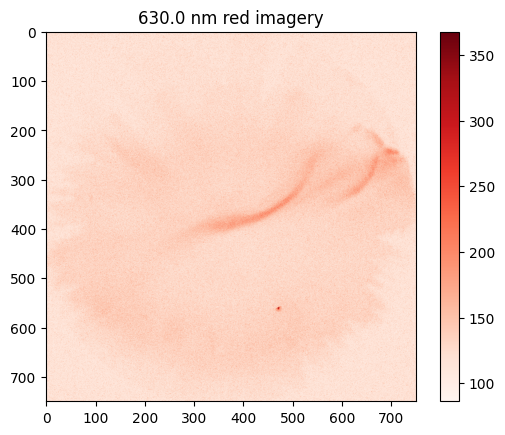

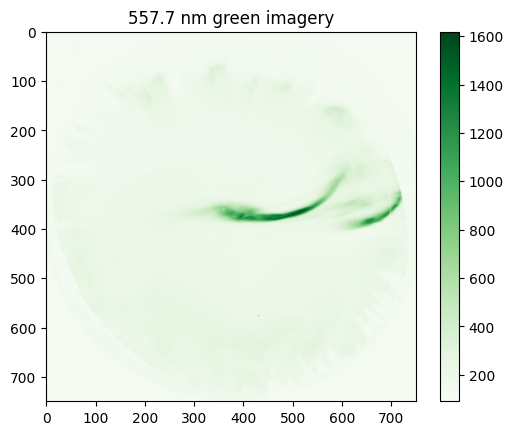

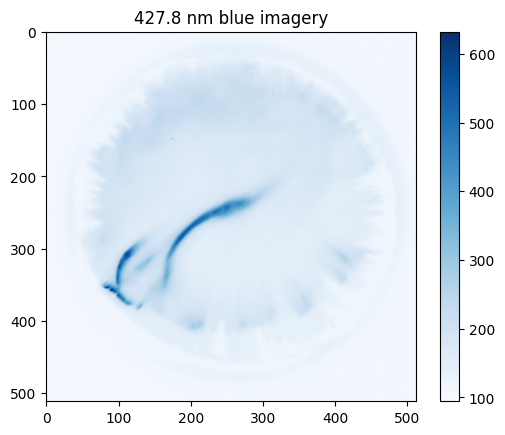

In [26]:
# Co-add the images
redimcoadd = (redim0+redim1+redim2)/3
greenimcoadd = (greenim0+greenim1+greenim2)/3
blueimcoadd = (blueim0+blueim1+blueim2)/3

plt.imshow(redimcoadd, cmap='Reds')
plt.title(f'{red_wavelength_nm} nm red imagery')
plt.colorbar()
plt.show()
plt.imshow(greenimcoadd, cmap='Greens')
plt.colorbar()
plt.title(f'557.7 nm green imagery')
plt.show()
plt.imshow(blueimcoadd, cmap='Blues')
plt.colorbar()
plt.title(f'{blue_wavelength_nm} nm blue imagery')
plt.show()


### Dark Frame Subtraction
The blue imagery has significant artifacts, so let's try a dark frame subtraction!  This is not necessarily a standard step.

In [27]:
blueimcoaddold = np.copy(blueimcoadd)
darkframe = iio.imread('biasframes/blue_bias_processed.png').astype('float')/10
darkframe -= np.mean(darkframe)

In [28]:
rawdarkframe = iio.imread('biasframes/blue_bias_raw.png').astype('float')/10
rawdarkframe -= np.mean(rawdarkframe)

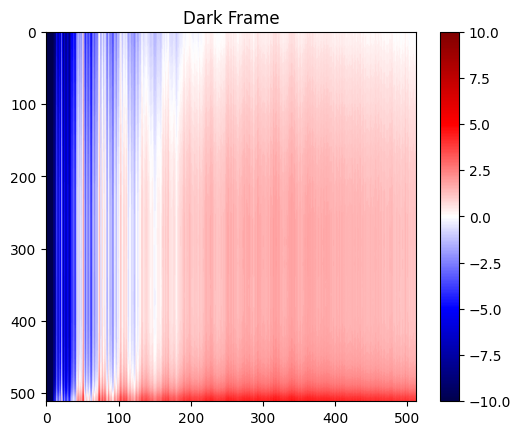

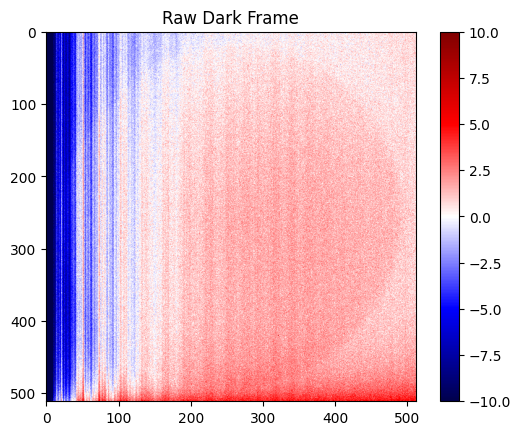

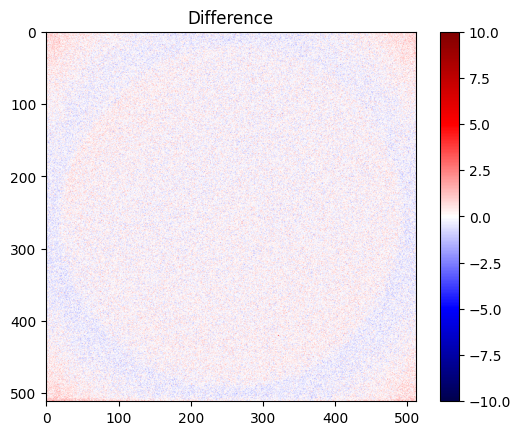

In [29]:
plt.imshow(darkframe,vmin=-10,vmax=10,cmap='seismic')
plt.colorbar()
plt.title('Dark Frame')
plt.show()
plt.imshow(rawdarkframe,vmin=-10,vmax=10,cmap='seismic')
plt.colorbar()
plt.title('Raw Dark Frame')
plt.show()
plt.imshow(rawdarkframe-darkframe,vmin=-10,vmax=10,cmap='seismic')
plt.colorbar()
plt.title('Difference')
plt.show()

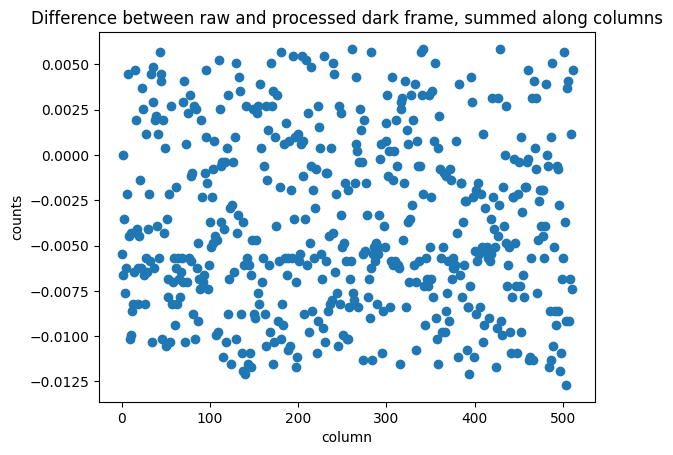

Text(0.5, 0, 'column')

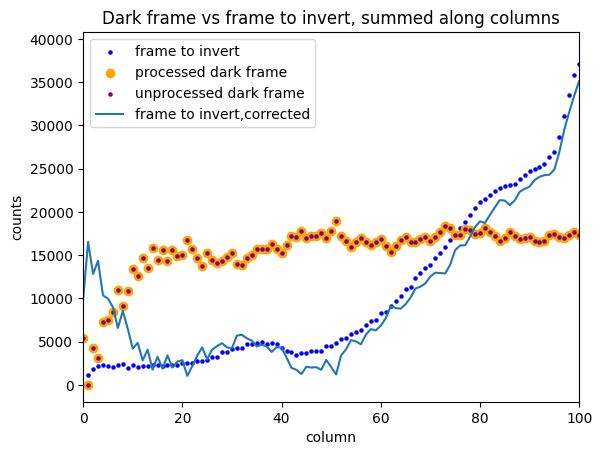

In [30]:
plt.scatter(np.linspace(0,511,512),((np.sum(rawdarkframe,axis=0)-np.amin(np.sum(rawdarkframe,axis=0)))-((np.sum(darkframe,axis=0)-np.amin(np.sum(darkframe,axis=0)))))/512,label='processed dark frame')
plt.title('Difference between raw and processed dark frame, summed along columns')
plt.ylabel('counts')
plt.xlabel('column')
plt.show()
plt.title('Dark frame vs frame to invert, summed along columns')
plt.scatter(np.linspace(0,511,512),np.sum(blueimcoaddold,axis=0)-np.amin(np.sum(blueimcoaddold,axis=0)),s=5,color='blue',label='frame to invert')
plt.scatter(np.linspace(0,511,512),(np.sum(darkframe,axis=0)-np.amin(np.sum(darkframe,axis=0))),color='orange',label='processed dark frame')
plt.scatter(np.linspace(0,511,512),(np.sum(rawdarkframe,axis=0)-np.amin(np.sum(rawdarkframe,axis=0))),s=5,color='purple',label='unprocessed dark frame')
plt.plot(np.linspace(0,511,512),np.sum(blueimcoaddold-darkframe,axis=0)-np.amin(np.sum(blueimcoaddold-darkframe,axis=0)),label='frame to invert,corrected')

plt.legend()
plt.xlim(0,100)
plt.ylabel('counts')
plt.xlabel('column')


In [31]:
blueimcoadd = blueimcoaddold-darkframe

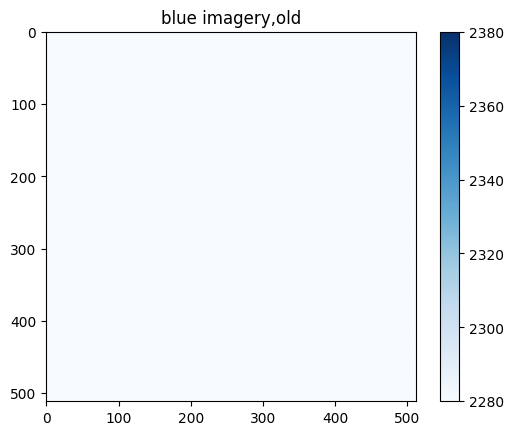

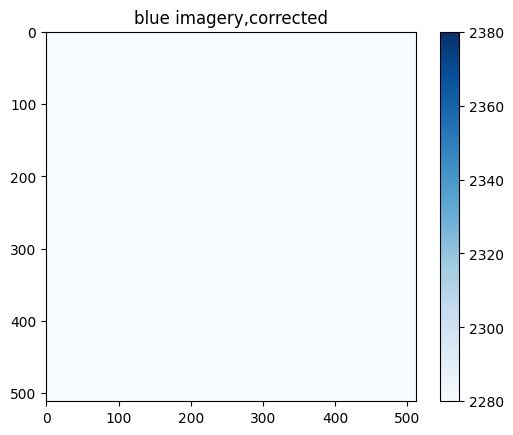

In [32]:
plt.imshow(blueimcoaddold,vmin=2280,vmax=2380, cmap='Blues')
plt.title('blue imagery,old')
plt.colorbar()
plt.show()
plt.imshow(blueimcoadd,vmin=2280,vmax=2380, cmap='Blues')
plt.title('blue imagery,corrected')
plt.colorbar()
plt.show()
# plt.imshow(blueimcoaddold-rawdarkframe,vmin=2280,vmax=2380)
# plt.title('blue imagery,corrected alternate')
# plt.colorbar()
# plt.show()

### Estimating Background Brightness

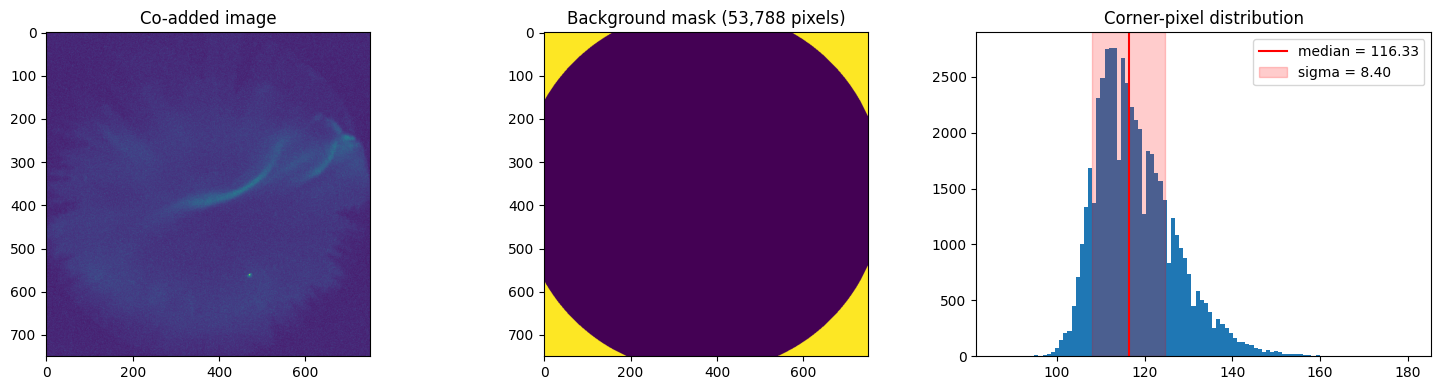

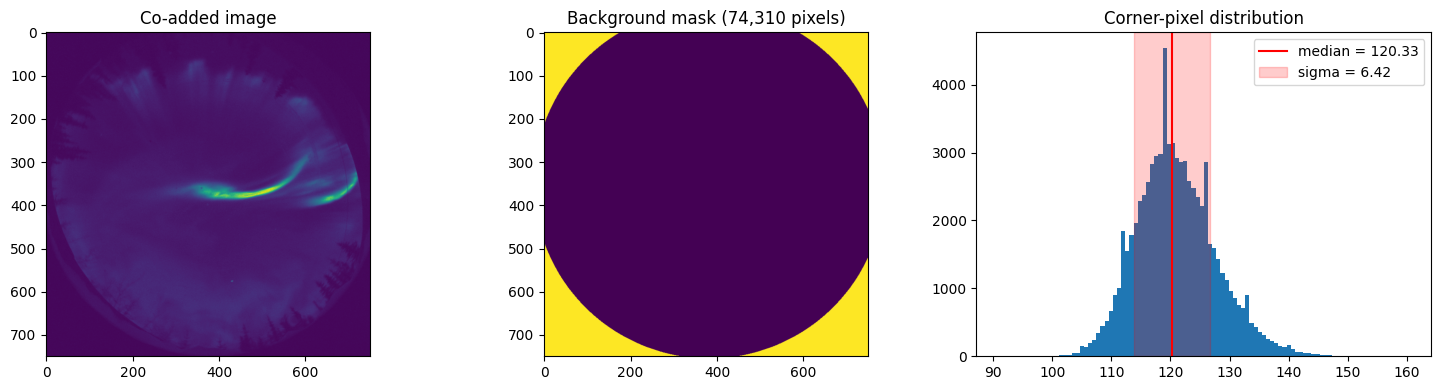

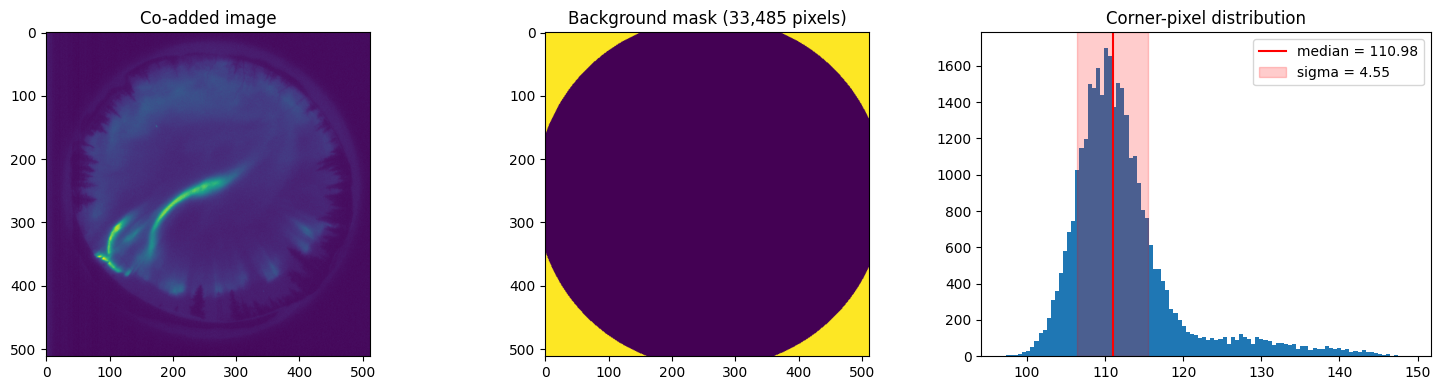

Red background:   116.33 ± 8.40 counts
Green background: 120.33 ± 6.42 counts
Blue background:  110.98 ± 4.55 counts


In [33]:
from scipy.ndimage import distance_transform_edt

background_edge_buffer_px = 80

def estimate_vee_background(image, skymap, edge_buffer_px=background_edge_buffer_px, plot=True):
    # Pixels rejected by the elevation mask, outside the usable sky FOV.
    outside_fov = np.isnan(skymap[0]) | np.isnan(skymap[1])

    # Distance from each outside-FOV pixel to the valid-sky boundary.
    distance_from_sky = distance_transform_edt(outside_fov)

    # Use only pixels well inside the detector corners.
    background_mask = (
        outside_fov
        & (distance_from_sky > edge_buffer_px)
        & np.isfinite(image)
    )

    values = image[background_mask]

    if values.size < 100:
        raise ValueError(
            f"Background mask contains only {values.size} pixels"
        )

    # Robust center and noise estimates.
    background = np.median(values)
    sigma = 1.4826 * np.median(np.abs(values - background))

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].imshow(image)
        axes[0].set_title("Co-added image")

        axes[1].imshow(background_mask)
        axes[1].set_title(
            f"Background mask ({values.size:,} pixels)"
        )

        axes[2].hist(values, bins=100)
        axes[2].axvline(
            background,
            color="red",
            label=f"median = {background:.2f}",
        )
        axes[2].axvspan(
            background - sigma,
            background + sigma,
            alpha=0.2,
            color="red",
            label=f"sigma = {sigma:.2f}",
        )
        axes[2].set_title("Corner-pixel distribution")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    return background, sigma, background_mask


redbgbright, redsig, red_background_mask = estimate_vee_background(
    redimcoadd,
    skymapred,
    edge_buffer_px=background_edge_buffer_px,
)

greenbgbright, greensig, green_background_mask = estimate_vee_background(
    greenimcoadd,
    skymapgreen,
    edge_buffer_px=background_edge_buffer_px,
)

bluebgbright, bluesig, blue_background_mask = estimate_vee_background(
    blueimcoadd,
    skymapblue,
    edge_buffer_px=background_edge_buffer_px,
)

print(f"Red background:   {redbgbright:.2f} ± {redsig:.2f} counts")
print(f"Green background: {greenbgbright:.2f} ± {greensig:.2f} counts")
print(f"Blue background:  {bluebgbright:.2f} ± {bluesig:.2f} counts")

### Wavelet Denoising
We use a Bayesian wavelet based denoising algorithm to blur the image as little as possible.
nshifts is a parameter controlling the shift-invariance of the wavelets, and should probably be set between 5 and 70, or so... 
Here we set nshifts=30 to speed up computation, but its default value is 50 (I probably set it higher than necessary)

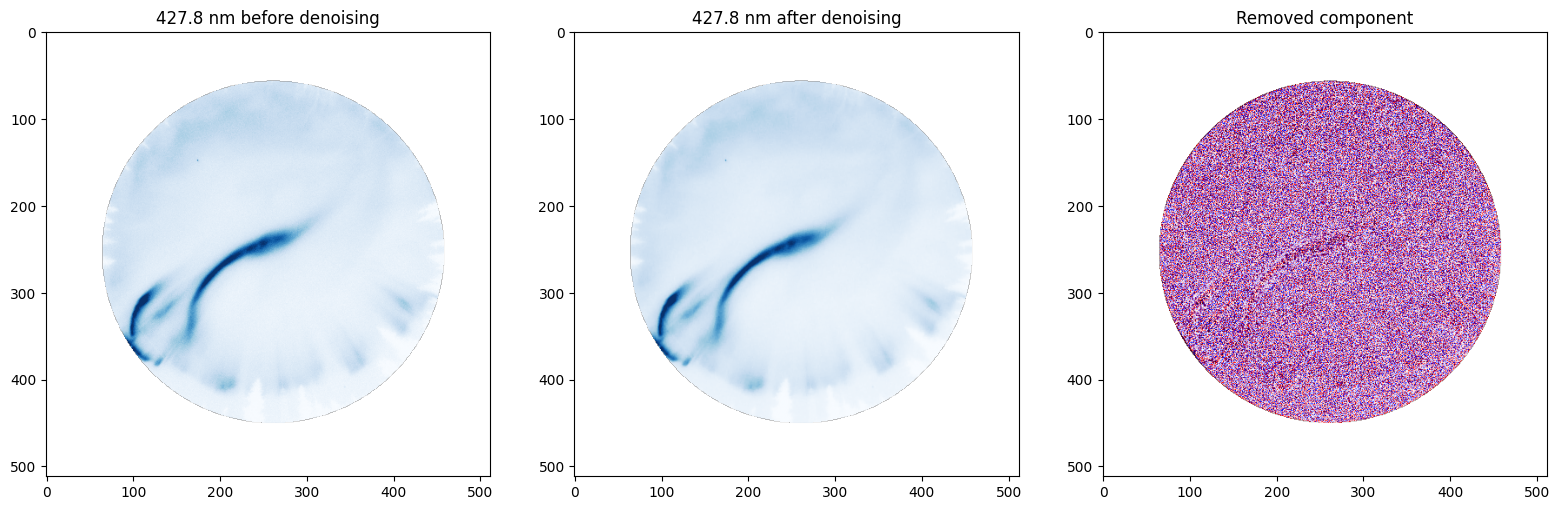

In [34]:
from skimage.restoration import cycle_spin, denoise_wavelet

wavelet_shifts = {
    "red": 3,
    "green": 3,
    "blue": 4,
}

def wavelet_denoise_vee(
    image,
    invalid_mask,
    background,
    sigma,
    max_shifts=3,
):
    image = np.asarray(image, dtype=float).copy()
    invalid_mask = np.asarray(invalid_mask, dtype=bool)

    if image.shape != invalid_mask.shape:
        raise ValueError(
            f"Image/mask shape mismatch: "
            f"{image.shape} versus {invalid_mask.shape}"
        )

    # Remove non-sky detector pixels from the denoising input.
    image[invalid_mask] = np.nan

    # Wavelet transforms cannot process NaNs. Filling with the fitted
    # background also avoids a sharp zero-valued edge around the sky.
    filled = np.where(
        np.isfinite(image),
        image,
        background,
    )

    denoised = cycle_spin(
        filled,
        func=denoise_wavelet,
        max_shifts=max_shifts,
        func_kw={
            "sigma": sigma,
            "method": "BayesShrink",
            "mode": "soft",
            "rescale_sigma": True,
        },
        workers=1,
        channel_axis=None,
    )

    # Restore the invalid camera region after denoising.
    denoised[invalid_mask] = np.nan

    return denoised

bmask = np.isnan(skymapblue[0]) | np.isnan(skymapblue[1])

blueimdenoisewavelet = wavelet_denoise_vee(
    blueimcoadd,
    bmask,
    bluebgbright,
    bluesig,
    max_shifts=wavelet_shifts["blue"],
)

valid_blue = ~bmask

vmin, vmax = np.nanpercentile(
    blueimcoadd[valid_blue],
    [1, 99.7],
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(
    np.where(valid_blue, blueimcoadd, np.nan),
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("427.8 nm before denoising")

axes[1].imshow(
    blueimdenoisewavelet,
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("427.8 nm after denoising")

residual = blueimcoadd - blueimdenoisewavelet
residual_limit = np.nanpercentile(
    np.abs(residual[valid_blue]),
    99,
)

axes[2].imshow(
    residual,
    cmap="seismic",
    vmin=-residual_limit,
    vmax=residual_limit,
)
axes[2].set_title("Removed component")

plt.tight_layout()
plt.show()

#### Compare Against Simulated Noise
Let's compare the residual from denoising to a simulated noise field from our background fitting

I'm very confused by this comparison.

Estimated input noise σ: 4.547 counts
Removed-component robust σ: 3.509 counts
Removed-component median: 0.000 counts


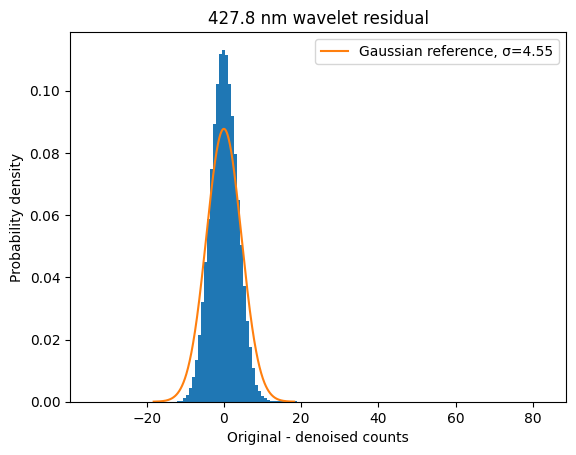

In [35]:
blue_residual_values = residual[
    valid_blue & np.isfinite(residual)
]

residual_center = np.median(blue_residual_values)
residual_sigma = (
    1.4826
    * np.median(
        np.abs(blue_residual_values - residual_center)
    )
)

print(f"Estimated input noise σ: {bluesig:.3f} counts")
print(f"Removed-component robust σ: {residual_sigma:.3f} counts")
print(f"Removed-component median: {residual_center:.3f} counts")

plt.hist(
    blue_residual_values,
    bins=150,
    density=True,
)

x = np.linspace(
    -4 * bluesig,
    4 * bluesig,
    500,
)

reference = np.exp(-(x**2) / (2 * bluesig**2))
reference /= np.trapezoid(reference, x)

plt.plot(
    x,
    reference,
    label=f"Gaussian reference, σ={bluesig:.2f}",
)

plt.xlabel("Original - denoised counts")
plt.ylabel("Probability density")
plt.title("427.8 nm wavelet residual")
plt.legend()
plt.show()

#### Apply Wavelet Denoising to All Three Channels

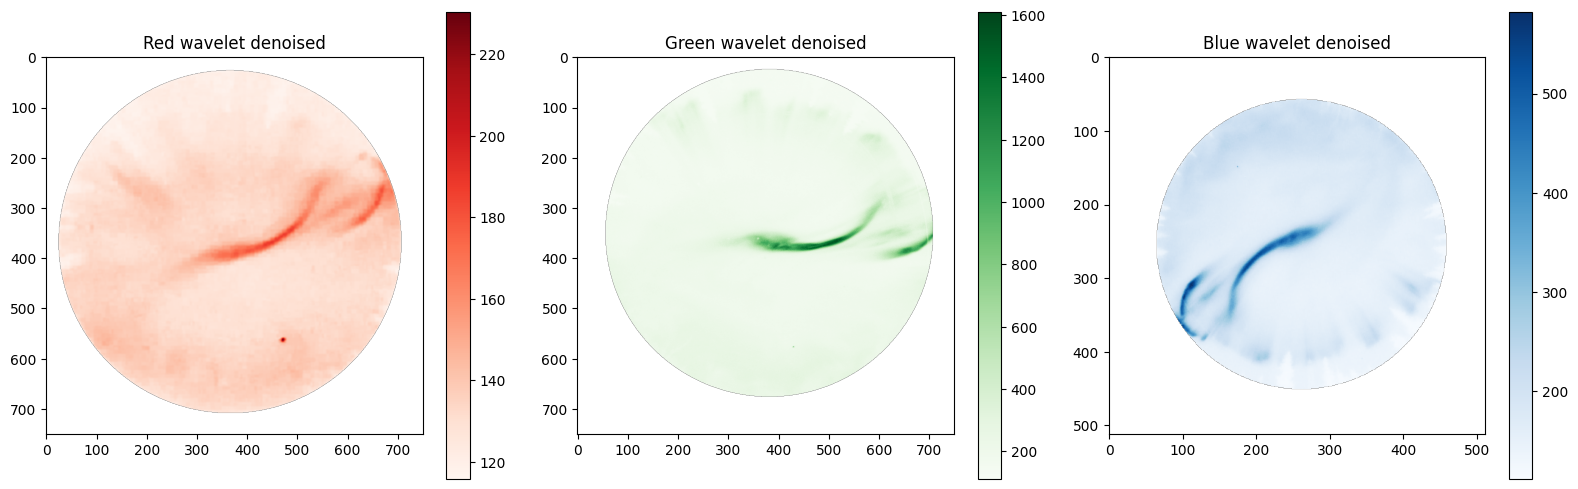

In [36]:
rmask = np.isnan(skymapred[0]) | np.isnan(skymapred[1])
gmask = np.isnan(skymapgreen[0]) | np.isnan(skymapgreen[1])
bmask = np.isnan(skymapblue[0]) | np.isnan(skymapblue[1])

redimdenoise = wavelet_denoise_vee(
    redimcoadd,
    rmask,
    redbgbright,
    redsig,
    max_shifts=wavelet_shifts["red"],
)

greenimdenoise = wavelet_denoise_vee(
    greenimcoadd,
    gmask,
    greenbgbright,
    greensig,
    max_shifts=wavelet_shifts["green"],
)

blueimdenoise = wavelet_denoise_vee(
    blueimcoadd,
    bmask,
    bluebgbright,
    bluesig,
    max_shifts=wavelet_shifts["blue"],
)

channels = [
    ("Red", redimdenoise, "Reds"),
    ("Green", greenimdenoise, "Greens"),
    ("Blue", blueimdenoise, "Blues"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, image, cmap) in zip(axes, channels):
    handle = ax.imshow(image, cmap=cmap)
    ax.set_title(f"{label} wavelet denoised")
    fig.colorbar(handle, ax=ax)

plt.tight_layout()
plt.show()

### Regridding
The skymap file contains the coordinates of all three images magnetically mapped to 110 km.  We want to define a regular geodetic grid and interpolat all three images to that grid.

In [37]:
from scipy.interpolate import griddata

bglat, bglon = skymapblue
gglat, gglon = skymapgreen
rglat, rglon = skymapred

common_grid_size = 512


def finite_coordinate_bounds(lat, lon):
    valid = np.isfinite(lat) & np.isfinite(lon)

    if not np.any(valid):
        raise ValueError("Coordinate array contains no valid pixels")

    return {
        "lat_min": np.min(lat[valid]),
        "lat_max": np.max(lat[valid]),
        "lon_min": np.min(lon[valid]),
        "lon_max": np.max(lon[valid]),
    }


def make_common_grid(skymaps, grid_size=512):
    bounds = [
        finite_coordinate_bounds(lat, lon)
        for lat, lon in skymaps
    ]

    # Intersection of the channel bounding boxes.
    lat_min = max(item["lat_min"] for item in bounds)
    lat_max = min(item["lat_max"] for item in bounds)
    lon_min = max(item["lon_min"] for item in bounds)
    lon_max = min(item["lon_max"] for item in bounds)

    if lat_min >= lat_max or lon_min >= lon_max:
        raise ValueError(
            "The wavelength skymaps have no common geographic bounds"
        )

    latitude = np.linspace(lat_min, lat_max, grid_size)
    longitude = np.linspace(lon_min, lon_max, grid_size)

    # Conventional array orientation:
    # axis 0 changes latitude; axis 1 changes longitude.
    gridlon, gridlat = np.meshgrid(
        longitude,
        latitude,
        indexing="xy",
    )

    return gridlat, gridlon


def regrid_image(image, oldlat, oldlon, gridlat, gridlon):
    image = np.asarray(image, dtype=float)
    oldlat = np.asarray(oldlat, dtype=float)
    oldlon = np.asarray(oldlon, dtype=float)

    if image.shape != oldlat.shape or image.shape != oldlon.shape:
        raise ValueError(
            f"Image/coordinate shape mismatch: image={image.shape}, "
            f"lat={oldlat.shape}, lon={oldlon.shape}"
        )

    valid = (
        np.isfinite(image)
        & np.isfinite(oldlat)
        & np.isfinite(oldlon)
    )

    if np.count_nonzero(valid) < 3:
        raise ValueError(
            "Not enough valid pixels for interpolation"
        )

    points = np.column_stack([
        oldlon[valid],
        oldlat[valid],
    ])

    targets = np.column_stack([
        gridlon.ravel(),
        gridlat.ravel(),
    ])

    interpolated = griddata(
        points,
        image[valid],
        targets,
        method="linear",
    )

    return interpolated.reshape(gridlat.shape)


gridlat, gridlon = make_common_grid(
    [
        (bglat, bglon),
        (gglat, gglon),
        (rglat, rglon),
    ],
    grid_size=common_grid_size,
)

blueimreg = regrid_image(
    blueimdenoise,
    bglat,
    bglon,
    gridlat,
    gridlon,
)

greenimreg = regrid_image(
    greenimdenoise,
    gglat,
    gglon,
    gridlat,
    gridlon,
)

redimreg = regrid_image(
    redimdenoise,
    rglat,
    rglon,
    gridlat,
    gridlon,
)

# Retain only locations covered by every wavelength.
common_valid = (
    np.isfinite(redimreg)
    & np.isfinite(greenimreg)
    & np.isfinite(blueimreg)
)

redimreg[~common_valid] = np.nan
greenimreg[~common_valid] = np.nan
blueimreg[~common_valid] = np.nan

# Grid increments using the conventional mesh orientation.
dlat = np.mean(np.diff(gridlat[:, 0]))
dlon = np.mean(np.diff(gridlon[0, :]))

mean_latitude = np.nanmean(gridlat)
dy_km = abs(dlat) * 111.0
dx_km = abs(dlon) * 111.0 * np.cos(np.deg2rad(mean_latitude))

print("Common-grid shape:", gridlat.shape)
print(f"Latitude spacing:  {dlat:.5f}° ≈ {dy_km:.2f} km")
print(f"Longitude spacing: {dlon:.5f}° ≈ {dx_km:.2f} km")
print(
    "Common valid pixels:",
    np.count_nonzero(common_valid),
    f"({100 * np.mean(common_valid):.1f}%)",
)

Common-grid shape: (512, 512)
Latitude spacing:  0.01249° ≈ 1.39 km
Longitude spacing: 0.03200° ≈ 1.39 km
Common valid pixels: 204627 (78.1%)


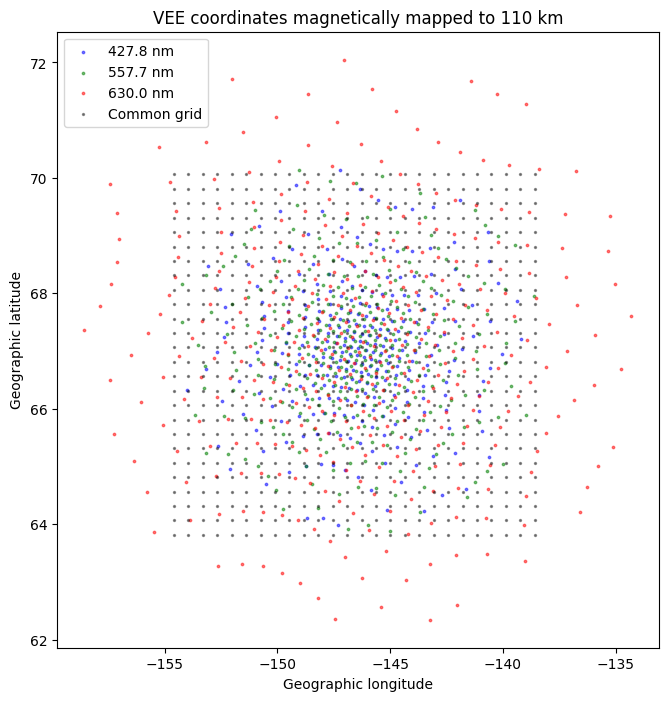

In [38]:
fig, ax = plt.subplots(figsize=(9, 8))

sample_blue = 20
sample_green = 30
sample_red = 30
sample_grid = 20

ax.scatter(
    bglon[::sample_blue, ::sample_blue],
    bglat[::sample_blue, ::sample_blue],
    s=3,
    color="blue",
    alpha=0.5,
    label="427.8 nm",
)

ax.scatter(
    gglon[::sample_green, ::sample_green],
    gglat[::sample_green, ::sample_green],
    s=3,
    color="green",
    alpha=0.5,
    label="557.7 nm",
)

ax.scatter(
    rglon[::sample_red, ::sample_red],
    rglat[::sample_red, ::sample_red],
    s=3,
    color="red",
    alpha=0.5,
    label=f"{red_wavelength_nm} nm",
)

ax.scatter(
    gridlon[::sample_grid, ::sample_grid],
    gridlat[::sample_grid, ::sample_grid],
    s=2,
    color="black",
    alpha=0.4,
    label="Common grid",
)

# Correct the visual distortion of longitude at high latitude.
ax.set_aspect(
    1 / np.cos(np.deg2rad(np.nanmean(gridlat)))
)

ax.set_xlabel("Geographic longitude")
ax.set_ylabel("Geographic latitude")
ax.set_title(
    f"VEE coordinates magnetically mapped to "
    f"{common_mapping_altitude_km:g} km"
)
ax.legend()
plt.show()

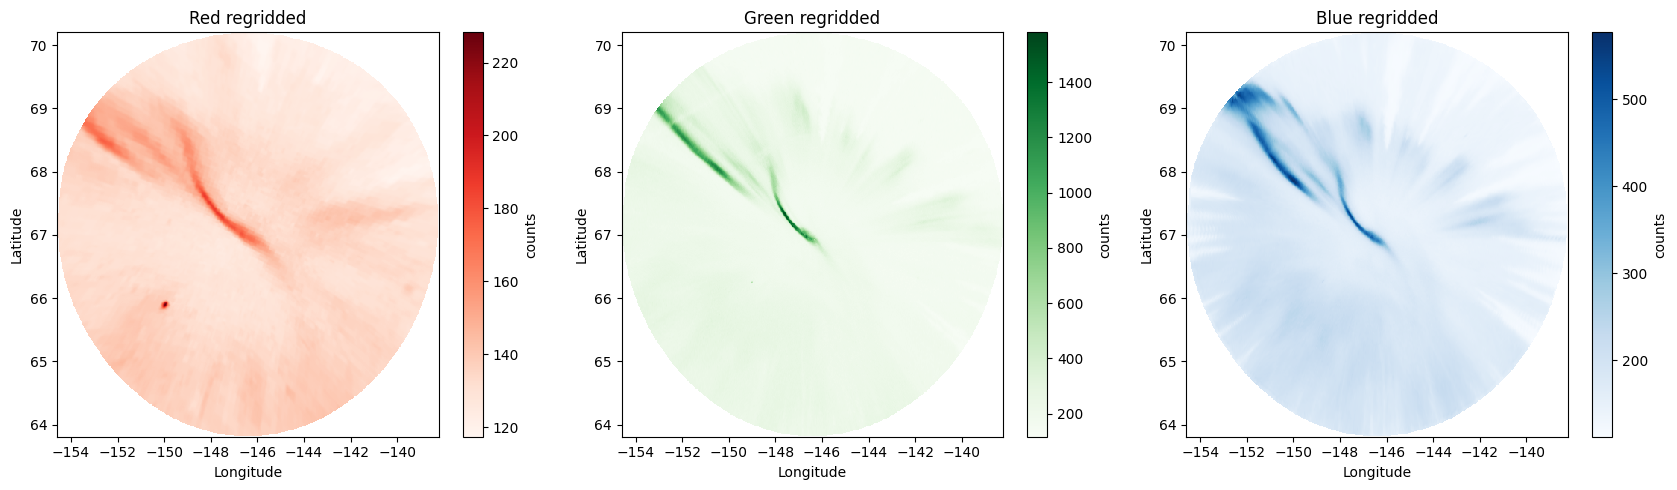

In [39]:
channels = [
    ("Red regridded", redimreg, "Reds"),
    ("Green regridded", greenimreg, "Greens"),
    ("Blue regridded", blueimreg, "Blues"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (title, image, cmap) in zip(axes, channels):
    handle = ax.pcolormesh(
        gridlon,
        gridlat,
        image,
        shading="auto",
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(handle, ax=ax, label="counts")

plt.tight_layout()
plt.show()

### Convert to Rayleighs
Convert the background-subtracted VEE 630.0 and 557.7 nm images using the calibration factors maintained in `asi_mapping`. The factors have units of Rayleigh-seconds per count. The 427.8 nm image remains in background-subtracted counts until a calibration is available.

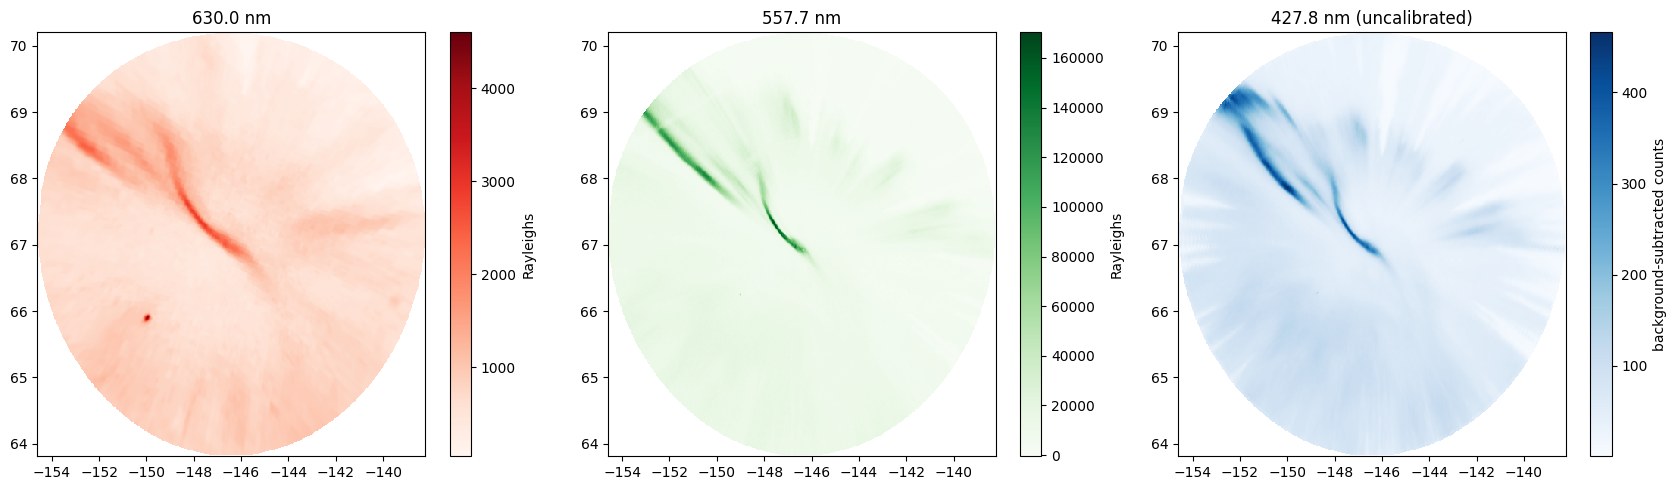

In [40]:
vee_calibration_r_s_per_count = {630.0: 37.0, 557.7: 35.0, 427.8: None}
vee_exposure_seconds = {630.0: 0.9, 557.7: 0.3, 427.8: 0.9}

if red_wavelength_nm != 630.0:
    raise ValueError('Only the VEE 630.0 nm red channel is calibrated; 844.6 nm is not yet supported')

def counts_to_rayleighs(image, background, wavelength_nm):
    factor = vee_calibration_r_s_per_count[wavelength_nm]
    if factor is None:
        raise ValueError(f'No VEE calibration is available for {wavelength_nm} nm')
    exposure = vee_exposure_seconds[wavelength_nm]
    return (np.asarray(image, dtype=float) - background) / exposure * factor

redray = counts_to_rayleighs(redimreg, redbgbright, 630.0)
greenray = counts_to_rayleighs(greenimreg, greenbgbright, 557.7)
bluecounts = blueimreg - bluebgbright

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
products = [
    ('630.0 nm', redray, 'Reds', 'Rayleighs'),
    ('557.7 nm', greenray, 'Greens', 'Rayleighs'),
    ('427.8 nm (uncalibrated)', bluecounts, 'Blues', 'background-subtracted counts'),
]
for ax, (title, image, cmap, units) in zip(axes, products):
    handle = ax.pcolormesh(gridlon, gridlat, image, shading='auto', cmap=cmap)
    ax.set_title(title)
    fig.colorbar(handle, ax=ax, label=units)
plt.tight_layout()
plt.show()


#### NaN Invalid Pixels
Background subtraction can produce non-positive brightnesses. Mask those pixels jointly in the two calibrated channels used by the red-green inversion. The uncalibrated blue image is not allowed to invalidate otherwise usable red-green pixels.

In [41]:
invalid_rg = (
    ~np.isfinite(redray)
    | ~np.isfinite(greenray)
    | (redray <= 0)
    | (greenray <= 0)
)
negatives = np.where(common_valid, invalid_rg.astype(float), np.nan)

Text(0.5, 1.0, 'Non-positive or invalid calibrated red/green brightness')

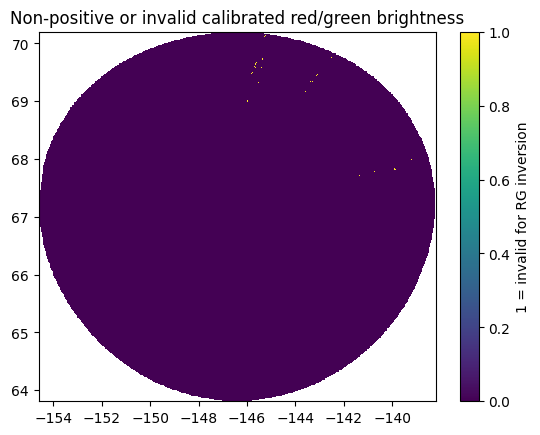

In [42]:
plt.pcolormesh(gridlon,gridlat,negatives)
plt.colorbar(label='1 = invalid for RG inversion')
plt.title('Non-positive or invalid calibrated red/green brightness')

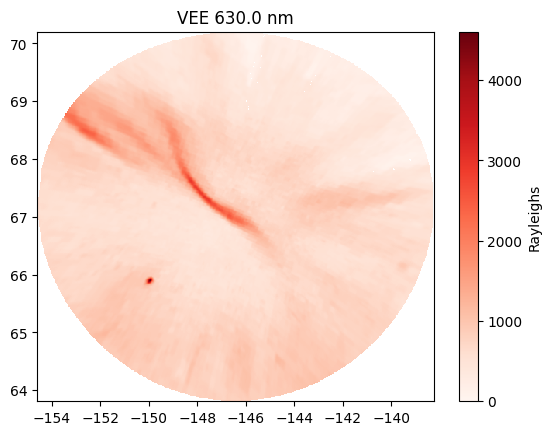

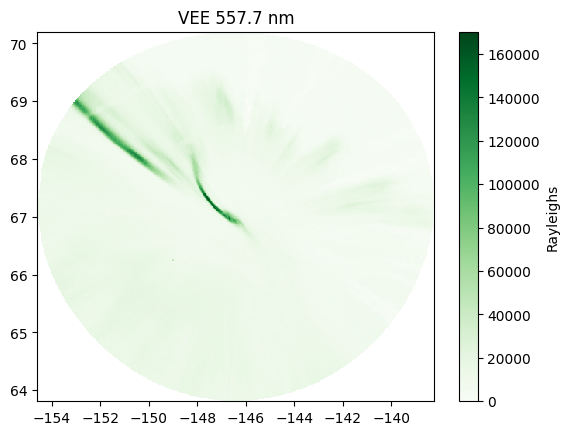

In [43]:
redray[invalid_rg] = np.nan
greenray[invalid_rg] = np.nan

plt.pcolormesh(gridlon, gridlat, redray, shading='auto', vmin=0., cmap='Reds')
plt.colorbar(label='Rayleighs')
plt.title('VEE 630.0 nm')
plt.show()

plt.pcolormesh(gridlon, gridlat, greenray, shading='auto', vmin=0., cmap='Greens')
plt.colorbar(label='Rayleighs')
plt.title('VEE 557.7 nm')
plt.show()

### Visualize the Calibrated Red and Green Channels
The blue channel is omitted from quantitative color composition because it does not yet have a VEE Rayleigh calibration.

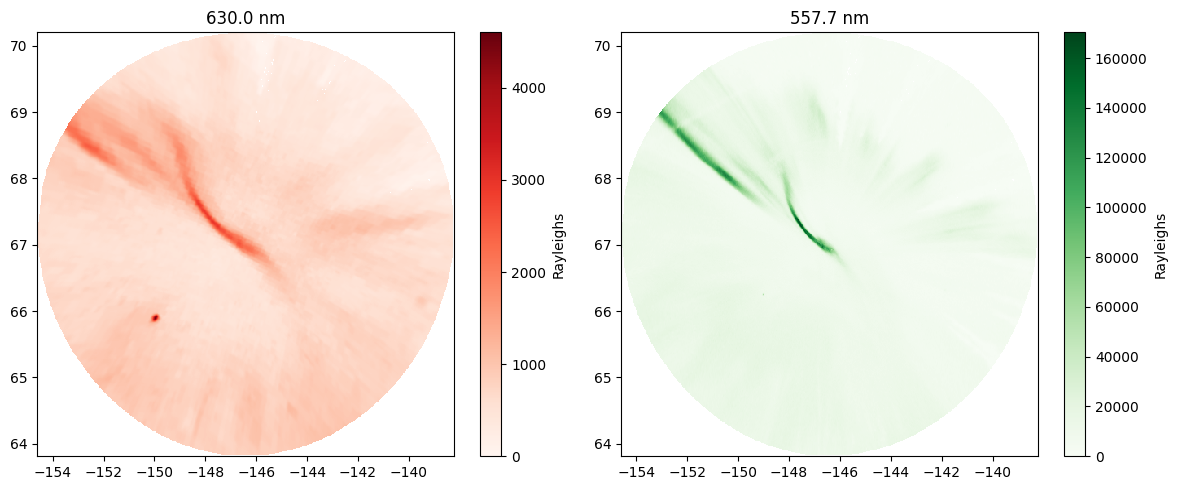

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, title, image, cmap in [
    (axes[0], '630.0 nm', redray, 'Reds'),
    (axes[1], '557.7 nm', greenray, 'Greens'),
]:
    handle = ax.pcolormesh(gridlon, gridlat, image, shading='auto', cmap=cmap, vmin=0)
    ax.set_title(title)
    fig.colorbar(handle, ax=ax, label='Rayleighs')
plt.tight_layout()
plt.show()

### Decimate
Decimate the 512×512 common grid before the experimental RG inversion to control its interpolation cost.

In [45]:
dec = 8

redraydec = redray[::dec,::dec]
greenraydec = greenray[::dec,::dec]
bluecountsdec = bluecounts[::dec,::dec]  # diagnostic only; not used by the inversion
decgridlat = gridlat[::dec,::dec]
decgridlon = gridlon[::dec,::dec]

In [46]:
print('Decimated inversion shape:', redraydec.shape)
print('Valid RG pixels:', np.count_nonzero(np.isfinite(redraydec + greenraydec)))

Decimated inversion shape: (64, 64)
Valid RG pixels: 3189


## Invert Calibrated Red and Green to Q and E0
Use the experimental red-green inversion without blue agreement checking. Blue calibration is not required for this path.

In [47]:
import asispectralinversion.inversion as inversion_module
expected_inversion_file = (project_root / 'src/asispectralinversion/inversion.py').resolve()
loaded_inversion_file = Path(inversion_module.__file__).resolve()
if loaded_inversion_file != expected_inversion_file:
    raise RuntimeError(
        f'Loaded stale package code from {loaded_inversion_file}. ' 
        'Restart the kernel and run the notebook from the top.'
    )
print('Using inversion code:', loaded_inversion_file)

qout, e0out = calculate_E0_Q_v2_RGonly(
    redraydec,
    greenraydec,
    None,
    v,
    minE0=150,
    checkagreement=False,
    generous=False,
    plot=False,
)


Using inversion code: /Users/anniepflaum/lab317/asispectralinversion/src/asispectralinversion/inversion.py


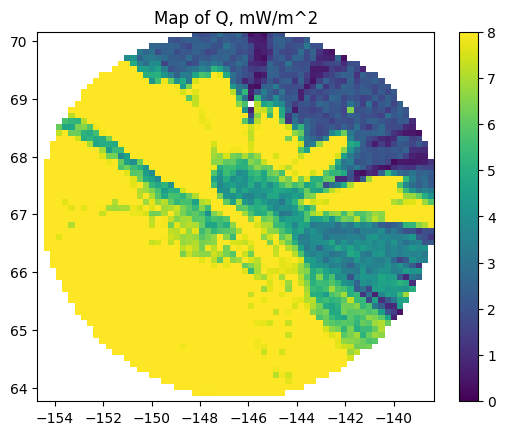

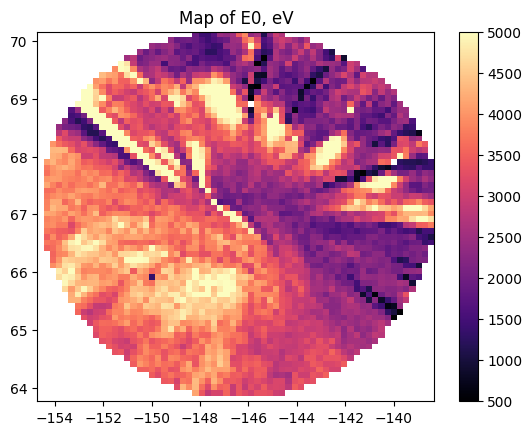

In [48]:
plt.title('Map of Q, mW/m^2')
plt.pcolormesh(decgridlon,decgridlat,qout,shading='nearest',vmin=0,vmax=8)
plt.colorbar()
plt.show()
plt.title('Map of E0, eV')
plt.pcolormesh(decgridlon,decgridlat,e0out,cmap='magma',vmin=500,vmax=5000,shading='nearest')
plt.colorbar()
plt.show()

## Calculate SigP, SigH
Note: The densities used for conductance estimation are zeroth order estimations above a certain altitude and should not be trusted!  In general, this calculation is not very good.  Recommended to take the inverted E0, Q and calculate conducances using an independent method.

In [49]:
SigP,SigH = calculate_Sig(qout,e0out,v,generous=False,plot=False)

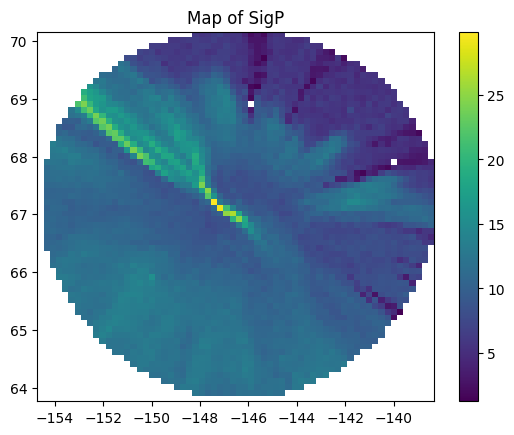

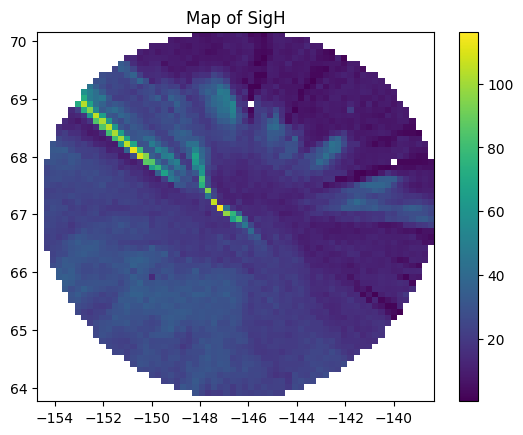

In [50]:
plt.title('Map of SigP')
plt.pcolormesh(decgridlon,decgridlat,SigP)
plt.colorbar()
plt.show()
plt.title('Map of SigH')
plt.pcolormesh(decgridlon,decgridlat,SigH)
plt.colorbar()
plt.show()

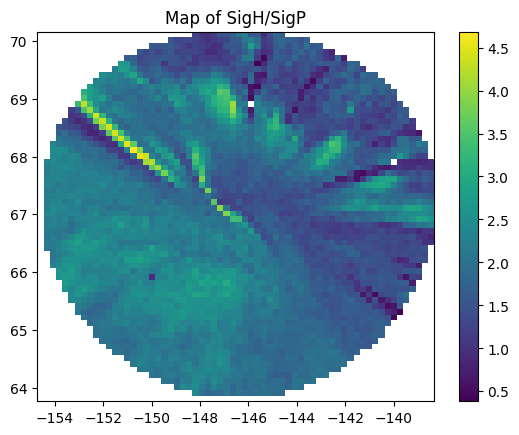

In [51]:
plt.title('Map of SigH/SigP')
plt.pcolormesh(decgridlon,decgridlat,SigH/SigP)
plt.colorbar()
plt.show()

In [52]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from asi_shared.missions import trajectory_config_tuples
from asi_shared.trajectory import build_traj_lookup, lookup_traj_position

target_time = "102400"

rocket_footprints = {}

trajectory_paths = {'397': run_config.trajectory_397, '398': run_config.trajectory_398}
for _key, tag, label, path in trajectory_config_tuples(
    "GNEISS", paths=trajectory_paths, date="20260210"
):
    # "green" tells this helper to map the rocket to 110 km,
    # which matches the notebook's common reference altitude.
    traj = build_traj_lookup(path, color="green")

    footprint_lat, footprint_lon = lookup_traj_position(
        traj,
        target_time,
    )

    rocket_footprints[tag] = {
        "label": label,
        "lat": footprint_lat,
        "lon": footprint_lon,
    }

rocket_footprints

{'397': {'label': '36.397',
  'lat': 67.45850372314453,
  'lon': -147.05856323242188},
 '398': {'label': '36.398',
  'lat': 67.21875762939453,
  'lon': -145.89768981933594}}

## Full RGB Inversion Status
The standard RGB inversion and RGB agreement check remain disabled until the VEE 427.8 nm channel has a Rayleigh calibration.

In [53]:
print('RGB inversion skipped: no VEE 427.8 nm Rayleigh calibration is available.')

RGB inversion skipped: no VEE 427.8 nm Rayleigh calibration is available.
